Track 2 - TF-IDF Motif Document
- ACR == Document, CRE == Words
- TF = Frequency of the motif within that ACR,
IDF = rarity of the motif across all ACRs (Reduces
weight of very common motifs to prevent clusters from
being dominated by these high-frequency motifs)

- Answer: Which relatively discriminative CREs are
more capable of distinguishing ACR classes?

Preprocessing:
- Parsing FASTA coordinates and sequences with Biopython
- FIMO.gff was cleaned as follows: Ran Tomtom on .meme file against itself to assign to a grouping to extremely similar motifs, mapped groupings to FIMO.gff and collapsed overlapping motifs from same grouping

In [39]:
from Bio import SeqIO
import pandas as pd

sequences = []
coords = []

#Fasta file for ACRs
for record in SeqIO.parse("/Users/avery/Downloads/dACR.fa", "fasta"):
    sequences.append(str(record.seq))
    coords.append(record.id)

gff = pd.read_csv(
    "/Users/avery/fimo_collapsed_with_metadata.csv"
)

def extract_alias(attr):
    for field in attr.split(";"):
        if field.startswith("Alias="):
            return field.split("=")[1]
    return None

gff["Alias"] = gff["attributes"].apply(extract_alias)
gff["sequence_id"] = gff["seqid"].astype(str).str.strip()

Motif TF-IDF

In [40]:
#Creating TF-IDF matrix where words are CREs and documents are ACRs
from sklearn.feature_extraction.text import TfidfVectorizer
# Create a mapping of ACR coordinates to their associated CREs
acr_to_cres = gff.groupby("sequence_id")["Alias"].apply(list).to_dict()
# Create a list of documents (ACRs) where each document is a space-separated string of its associated CREs
documents = []
for coord in coords:
    cres = acr_to_cres.get(coord, [])
    documents.append(" ".join(cres))
# Initialize the TF-IDF vectorizer and transform the documents into a TF-IDF matrix
vectorizer = TfidfVectorizer(lowercase=False)
tfidf_matrix = vectorizer.fit_transform(documents)
# Convert the TF-IDF matrix to a DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=coords)
print(tfidf_df.head())

                   AGL6  AS2  AT4G12670      BPC1      BPC5      BPC6  \
Chr1_1948to3564     0.0  0.0        0.0  0.000000  0.000000  0.000000   
Chr1_8549to9023     0.0  0.0        0.0  0.000000  0.727897  0.685687   
Chr1_13478to14410   0.0  0.0        0.0  0.653726  0.326127  0.614430   
Chr1_14678to15114   0.0  0.0        0.0  0.000000  0.000000  0.000000   
Chr1_16429to16975   0.0  0.0        0.0  1.000000  0.000000  0.000000   

                       CDF5  DOF1  DOF3      DOF5  ...  ERF104  ERF2  ERF5  \
Chr1_1948to3564    0.697705   0.0   0.0  0.716385  ...     0.0   0.0   0.0   
Chr1_8549to9023    0.000000   0.0   0.0  0.000000  ...     0.0   0.0   0.0   
Chr1_13478to14410  0.000000   0.0   0.0  0.297927  ...     0.0   0.0   0.0   
Chr1_14678to15114  0.000000   0.0   0.0  0.000000  ...     0.0   0.0   0.0   
Chr1_16429to16975  0.000000   0.0   0.0  0.000000  ...     0.0   0.0   0.0   

                   ERF9  NAC020  RAMOSA1  RAP2  TCP14  TRP1  TRP2  
Chr1_1948to3564     0.0 

TF-IDF Clustering of ACR Sequences

k-means

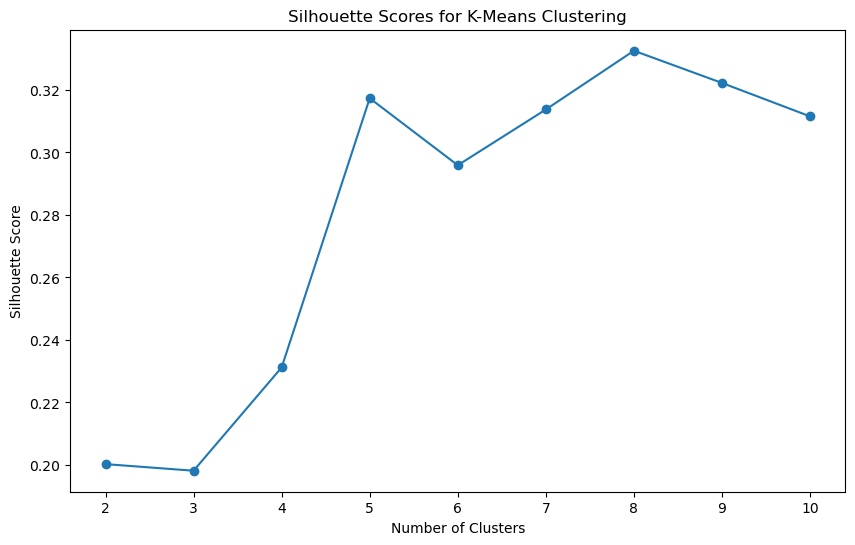

In [41]:
#k-means clustering of the TF-IDF matrix ACRs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# Determine the optimal number of clusters using silhouette scores
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(tfidf_df)
    silhouette_avg = silhouette_score(tfidf_df, cluster_labels, metric='cosine')
    silhouette_scores.append(silhouette_avg)
# Plot silhouette scores to visualize the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

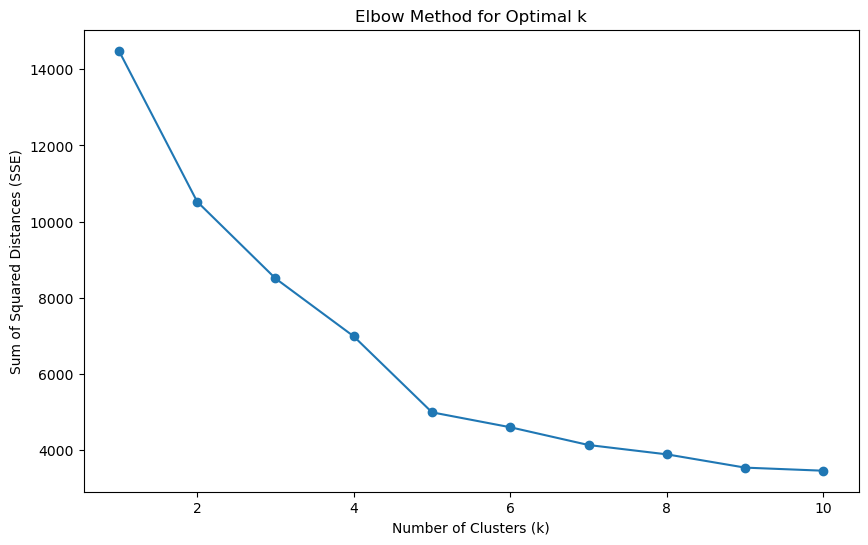

In [42]:
#k-means elbow method to determine optimal k
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Calculate the sum of squared distances for different values of k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_df)
    sse.append(kmeans.inertia_)
# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.show()

Hierarchical Clustering

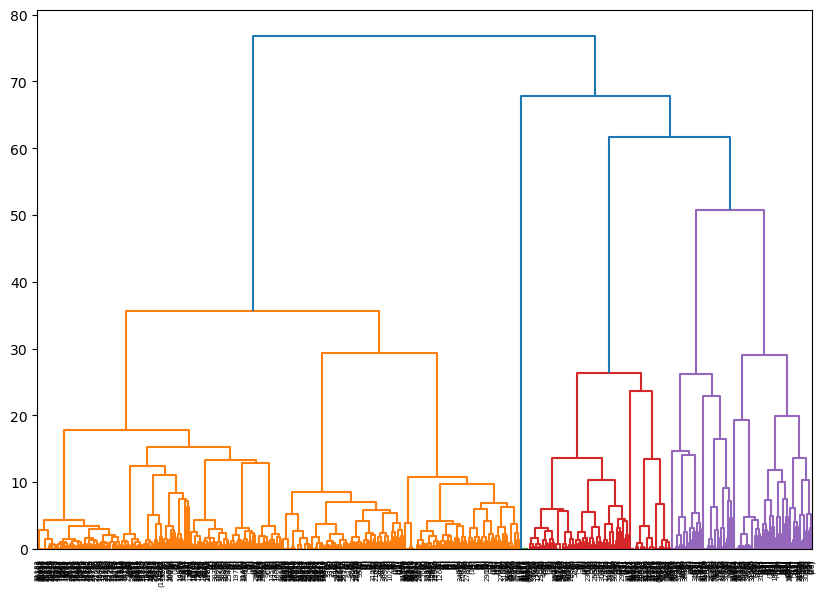

In [43]:
# Hierarchical Clustering
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

X_tfidf = tfidf_df.drop(
    columns=["kmeans_cluster", "hierarchical_cluster"],
    errors="ignore"
)

plt.figure(figsize=(10,7))
sch.dendrogram(
    sch.linkage(X_tfidf, method="ward"),
    truncate_mode="level",
    p=10
)
plt.show()

In [44]:
#K-means and hierarchical Clustering with 5 clusters
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

X = tfidf_df.copy()

kmeans_labels = KMeans(
    n_clusters=5,
    random_state=42
).fit_predict(X)

hierarchical_labels = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
).fit_predict(X)

results = X.copy()
results["kmeans_cluster"] = kmeans_labels
results["hierarchical_cluster"] = hierarchical_labels

Cluster Analyses

In [45]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

##########################################################
# FEATURE MATRIX
##########################################################
X = tfidf_df.drop(
    columns=[
        "kmeans_cluster",
        "hierarchical_cluster"
    ],
    errors="ignore"
)

##########################################################
# KMEANS STABILITY
##########################################################
def kmeans_stability(X, n_clusters, runs=10):
    """
    Average Adjusted Rand Index across multiple KMeans runs.
    """
    label_sets = []

    for seed in range(runs):
        labels = KMeans(
            n_clusters=n_clusters,
            random_state=seed,
            n_init=10
        ).fit_predict(X)

        label_sets.append(labels)

    ari_scores = []

    for i in range(runs):
        for j in range(i + 1, runs):
            ari_scores.append(
                adjusted_rand_score(
                    label_sets[i],
                    label_sets[j]
                )
            )

    return np.mean(ari_scores)

##########################################################
# EVALUATION
##########################################################
def evaluate(X, labels, method):
    labels = np.asarray(labels)
    mask = labels != -1
    X_valid = X.loc[mask]
    labels_valid = labels[mask]

    cluster_sizes = (
        pd.Series(labels_valid)
        .value_counts()
    )

    if len(cluster_sizes) > 1:

        silhouette = silhouette_score(
            X_valid,
            labels_valid
        )

        calinski = calinski_harabasz_score(
            X_valid,
            labels_valid
        )

        davies = davies_bouldin_score(
            X_valid,
            labels_valid
        )

    else:

        silhouette = np.nan
        calinski = np.nan
        davies = np.nan

    if method == "KMeans":

        stability = kmeans_stability(
            X_valid,
            len(cluster_sizes)
        )

    else:

        stability = np.nan

    return {

        "Method": method,

        "Clusters":
            len(cluster_sizes),

        "Largest Cluster":
            cluster_sizes.max(),

        "Smallest Cluster":
            cluster_sizes.min(),

        "Silhouette":
            silhouette,

        "Calinski-Harabasz":
            calinski,

        "Davies-Bouldin":
            davies,

        "ARI Stability":
            stability

    }

results = [
    evaluate(
        X,
        kmeans_labels,
        "KMeans"
    ),
    evaluate(
        X,
        hierarchical_labels,
        "Hierarchical")]

results_df = pd.DataFrame(results)

results_df.to_csv(
    "tfidf_cluster_evaluation_track2.csv",
    index=False
)

print(results_df)

         Method  Clusters  Largest Cluster  Smallest Cluster  Silhouette  \
0        KMeans         5            13521              3100    0.599663   
1  Hierarchical         5            14869              3323    0.543710   

   Calinski-Harabasz  Davies-Bouldin  ARI Stability  
0       14901.759216        0.968589       0.999498  
1       10924.688230        1.072559            NaN  


Functional Analysis

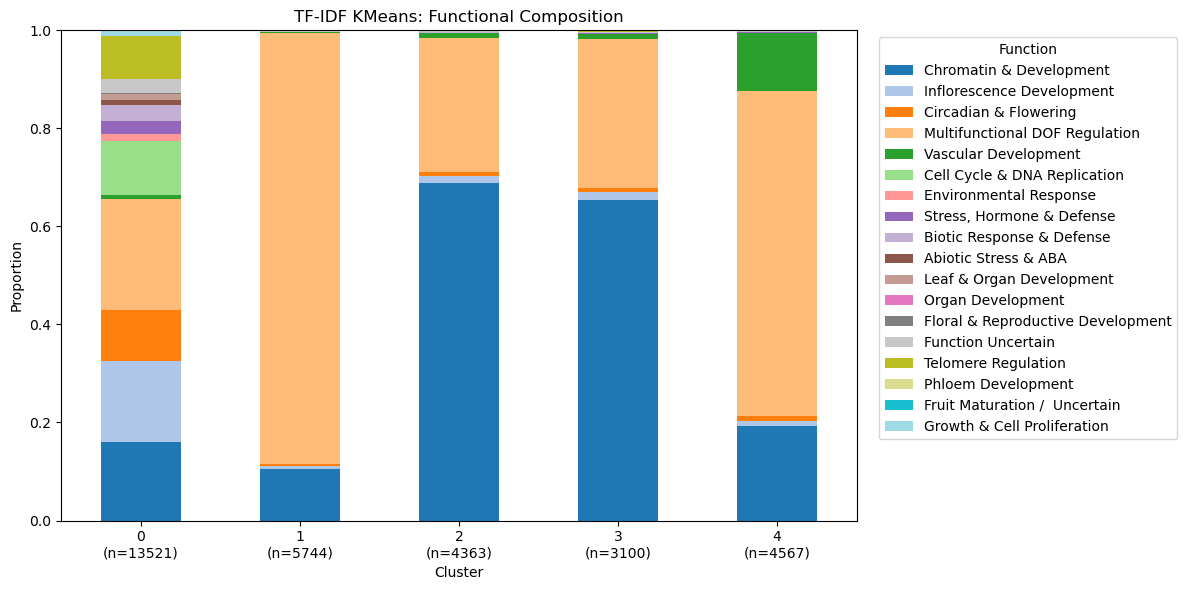

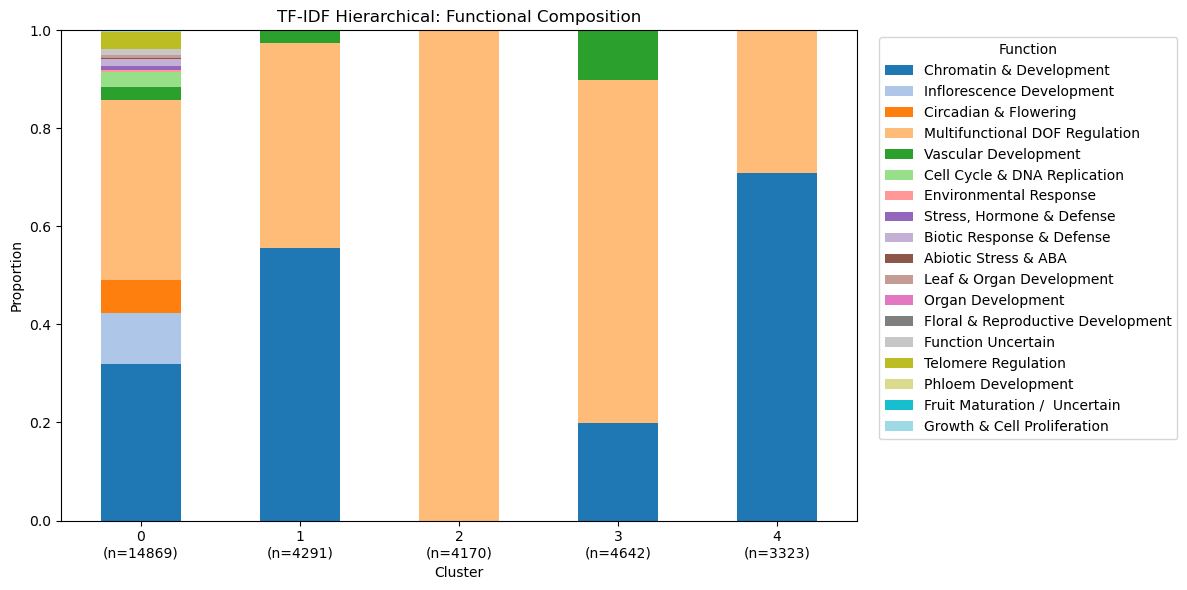

In [55]:
import matplotlib.pyplot as plt

##########################################################
# FUNCTION DEFINITIONS
##########################################################

functional_groups = {
    'Chromatin & Development': ['BPC1', 'BPC5', 'BPC6'],
    'Inflorescence Development': ['RAMOSA1'],
    'Circadian & Flowering': ['CDF5'],
    'Multifunctional DOF Regulation': ['DOF3.6', 'DOF5.1', 'DOF3.4', 'DOF1.5'],
    'Vascular Development': ['DOF5.8'],
    'Cell Cycle & DNA Replication': ['E2FD', 'E2FE'],
    'Environmental Response': ['DREB2D', 'ERF095'],
    'Stress, Hormone & Defense': ['ERF014', 'ERF057', 'ERF091', 'ERF104', 'ERF2', 'ERF5'],
    'Biotic Response & Defense': ['ERF9'],
    'Abiotic Stress & ABA': ['RAP2-6'],
    'Leaf & Organ Development': ['AS2'],
    'Organ Development': ['LOB'],
    'Floral & Reproductive Development': ['AGL6'],
    'Function Uncertain': ['AT4G12670'],
    'Telomere Regulation': ['TRP1', 'TRP2'],
    'Phloem Development': ['NAC020'],
    'Fruit Maturation /  Uncertain': ['NAC058'],
    'Growth & Cell Proliferation': ['TCP14']
}


alias_to_function = {
    motif: func
    for func, motifs in functional_groups.items()
    for motif in motifs
}

##########################################################
# FUNCTION ANNOTATION (ONLY IF NOT ALREADY PRESENT)
##########################################################

if "Function" not in gff.columns:
    gff["Alias"] = gff["attributes"].str.extract(r"Alias=([^;]+)")
    gff["Function"] = gff["Alias"].map(alias_to_function)

if "sequence_id" not in gff.columns:
    gff["sequence_id"] = gff["seqid"].astype(str).str.strip()

##########################################################
# FUNCTION MAPPING
##########################################################

all_functions = list(functional_groups.keys())

##########################################################
# FUNCTIONAL COMPOSITION
##########################################################

def get_cluster_composition(cluster_labels):

    # Build mapping from sequence IDs to cluster labels
    cluster_map = dict(zip(coords, cluster_labels))

    temp = gff.copy()

    temp["cluster"] = temp["sequence_id"].map(cluster_map)

    temp = temp.dropna(subset=["Function", "cluster"])

    counts = (
        pd.crosstab(
            temp["cluster"],
            temp["Function"]
        )
        .reindex(columns=all_functions, fill_value=0)
    )

    proportions = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    cluster_sizes = (
        pd.Series(cluster_labels)
        .value_counts()
        .sort_index()
    )

    return proportions, cluster_sizes

##########################################################
# PLOTTING
##########################################################

def plot_stacked(df, cluster_sizes, title):

    ax = df.plot(
        kind="bar",
        stacked=True,
        figsize=(12,6),
        colormap="tab20"
    )

    labels = [
        f"{cluster}\n(n={cluster_sizes.loc[cluster]})"
        for cluster in df.index
    ]

    ax.set_xticklabels(labels, rotation=0)

    plt.ylabel("Proportion")
    plt.xlabel("Cluster")
    plt.title(title)
    plt.ylim(0,1)

    plt.legend(
        title="Function",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

##########################################################
# PLOTS
##########################################################
plots = [
    ("TF-IDF KMeans", kmeans_labels),
    ("TF-IDF Hierarchical", hierarchical_labels)
]

for title, labels in plots:
    composition, cluster_sizes = get_cluster_composition(labels)

    plot_stacked(
        composition,
        cluster_sizes,
        f"{title}: Functional Composition"
    )

In [53]:
from scipy.stats import chi2_contingency
from scipy.stats import entropy

##########################################################
# BIOLOGICAL EVALUATION
##########################################################

def biological_summary(cluster_labels, method):

    temp = gff.copy()

    cluster_map = dict(zip(coords, cluster_labels))
    temp["cluster"] = temp["sequence_id"].map(cluster_map)
    temp = temp.dropna(subset=["Function", "cluster"])

    ######################################################
    # Cluster sizes (number of ACRs)
    ######################################################

    cluster_sizes = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

    ######################################################
    # Contingency table
    ######################################################

    counts = (
        pd.crosstab(
            temp["cluster"],
            temp["Function"]
        )
        .reindex(columns=all_functions, fill_value=0)
    )

    ######################################################
    # Chi-square
    ######################################################

    chi_counts = counts.loc[:, counts.sum(axis=0) > 0]

    chi2, p, dof, expected = chi2_contingency(chi_counts)

    ######################################################
    # Proportions
    ######################################################

    proportions = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    ######################################################
    # Summary table
    ######################################################

    rows = []

    for cluster in proportions.index:

        top3 = (
            proportions.loc[cluster]
            .sort_values(ascending=False)
            .head(3)
        )

        shannon = entropy(
            proportions.loc[cluster],
            base=2
        )

        rows.append({

            "Method": method,

            "Chi-square p": "<0.001" if p < 0.001 else f"{p:.3f}",

            "Cluster": cluster,

            "Cluster Size (ACRs)": int(cluster_sizes.loc[cluster]),

            "Shannon Diversity Index": round(shannon, 3),

            "Top Function 1": top3.index[0],
            "Top 1 (%)": round(top3.iloc[0] * 100, 2),

            "Top Function 2": top3.index[1],
            "Top 2 (%)": round(top3.iloc[1] * 100, 2),

            "Top Function 3": top3.index[2],
            "Top 3 (%)": round(top3.iloc[2] * 100, 2)

        })

    return pd.DataFrame(rows)

##########################################################
# RUN
##########################################################

bio_results = pd.concat([

    biological_summary(
        kmeans_labels,
        "KMeans"
    ),

    biological_summary(
        hierarchical_labels,
        "Hierarchical"
    )

], ignore_index=True)

bio_results.to_csv(
    "track2_biological_summary.csv",
    index=False
)

print(bio_results)

         Method Chi-square p  Cluster  Cluster Size (ACRs)  \
0        KMeans       <0.001        0                13521   
1        KMeans       <0.001        1                 5744   
2        KMeans       <0.001        2                 4363   
3        KMeans       <0.001        3                 3100   
4        KMeans       <0.001        4                 4567   
5  Hierarchical       <0.001        0                14869   
6  Hierarchical       <0.001        1                 4291   
7  Hierarchical       <0.001        2                 4170   
8  Hierarchical       <0.001        3                 4642   
9  Hierarchical       <0.001        4                 3323   

   Shannon Diversity Index                  Top Function 1  Top 1 (%)  \
0                    3.171  Multifunctional DOF Regulation      22.70   
1                    0.643  Multifunctional DOF Regulation      87.82   
2                    1.153         Chromatin & Development      68.80   
3                    1.21